In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import numpy as np
from pyproj import Transformer
from shapely.geometry import Point
import rasterio
import rioxarray
from scipy.spatial import cKDTree

In [2]:
# Load Thailand map and get bounds
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap = thailandmap.to_crs('EPSG:4326')
min_lon, min_lat, max_lon, max_lat = thailandmap.union_all().bounds


In [3]:
### Optimized version - Direct wetland distance and SI calculation ###
# Load and prepare data
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap = thailandmap.to_crs('EPSG:4326')
min_lon, min_lat, max_lon, max_lat = thailandmap.union_all().bounds

# Load and subset land cover data. Source latitude is descending, so slice max_lat -> min_lat first.
xr_landuse = xr.open_dataset('Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc')
xr_landuse = xr_landuse.sel(lat=slice(max_lat, min_lat), lon=slice(min_lon, max_lon))
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')
lccs_resolution = 300  # meters

# Extract wetland/waterbody areas from the selected LCCS class.
wetland_mask = xr_landuse['lccs_class'] == 210

# Get all coordinates as arrays
lats = xr_landuse['lat'].values
lons = xr_landuse['lon'].values
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Get wetland points in lat/lon
wetland_indices = np.where(wetland_mask.values)
wetland_lons = lon_grid[wetland_indices]
wetland_lats = lat_grid[wetland_indices]
if len(wetland_lons) == 0:
    raise ValueError('No wetland/waterbody cells found for LCCS class 210 in the Thailand subset.')

# Transform to a projected CRS for meter-based distances.
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32647', always_xy=True)
wetland_x, wetland_y = transformer.transform(wetland_lons, wetland_lats)
wetland_points_proj = np.column_stack([wetland_x, wetland_y])

# Transform all grid points
all_x, all_y = transformer.transform(lon_grid.ravel(), lat_grid.ravel())
all_points_proj = np.column_stack([all_x, all_y])

# Build KDTree for efficient spatial queries
tree = cKDTree(wetland_points_proj)
distances, _ = tree.query(all_points_proj, k=1, workers=-1)
distance_grid = distances.reshape(lon_grid.shape)

# Create xarray with distances
xr_distance = xr.Dataset(
    {'distance': (['lat', 'lon'], distance_grid.astype('float32'))},
    coords={'lat': lats, 'lon': lons}
)

print('Distance calculation complete')
print(f'Grid shape: {distance_grid.shape}')
print(f'wetland points found: {len(wetland_points_proj)}')
print(f'Min distance: {np.min(distances):.2f}m, Max distance: {np.max(distances):.2f}m')


Distance calculation complete
Grid shape: (5346, 2985)
wetland points found: 5980971
Min distance: 0.00m, Max distance: 133878.80m


In [4]:
# Load land cover suitability indices
xr_landuse_si = xr.open_dataset('Output\\xr_SI_Landcover.nc')

# Create SI variables based on distance thresholds
dist = xr_distance['distance']

# SI calculations using vectorized operations
xr_si = xr.Dataset()

# BGEC and Biomass: 0 if < 500m + resolution, else 3
threshold_bgec_biomass = 500 + lccs_resolution
xr_si['SI_BGEC'] = xr.where(dist < threshold_bgec_biomass, 0, 3)
xr_si['SI_Biomass'] = xr.where(dist < threshold_bgec_biomass, 0, 3)

# Solar and Wind: 0 if < 400m + resolution, else 3
threshold_solar_wind = 400 + lccs_resolution
xr_si['SI_Solar'] = xr.where(dist < threshold_solar_wind, 0, 3)
xr_si['SI_Wind'] = xr.where(dist < threshold_solar_wind, 0, 3)

# BGWW: 0 if < 500m + resolution, else 3
xr_si['SI_BGWW'] = xr.where(dist < threshold_bgec_biomass, 0, 3)

# MSW and IEW: tiered thresholds
threshold_msw1 = 300 + lccs_resolution
threshold_msw2 = 600 + lccs_resolution
threshold_msw3 = 900 + lccs_resolution
xr_si['SI_MSW'] = xr.where(dist < threshold_msw1, 0,
                          xr.where(dist < threshold_msw2, 1,
                                  xr.where(dist < threshold_msw3, 2, 3)))

xr_si['SI_IEW'] = xr_si['SI_MSW'].copy()  # Same thresholds as MSW

# Mask with land cover SI (set to 0 where land cover SI is 0)
for var in ['SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']:
    xr_si[var] = xr.where(xr_landuse_si[var] == 0, 0, xr_si[var])

print(xr_si)

<xarray.Dataset> Size: 447MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


In [5]:
# Save to NetCDF
xr_si.to_netcdf(path='Output\\xr_SI_Distancetowetland.nc')
print("Saved xr_SI_Distancetowetland.nc")
print(xr_si)

Saved xr_SI_Distancetowetland.nc
<xarray.Dataset> Size: 447MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


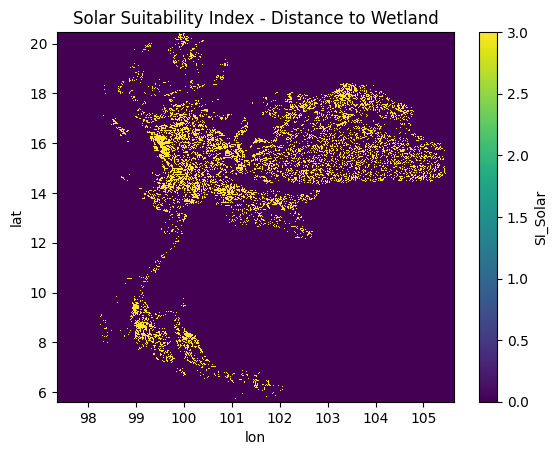

In [6]:
xr_si['SI_Solar'].plot()
plt.title('Solar Suitability Index - Distance to Wetland')
plt.show()

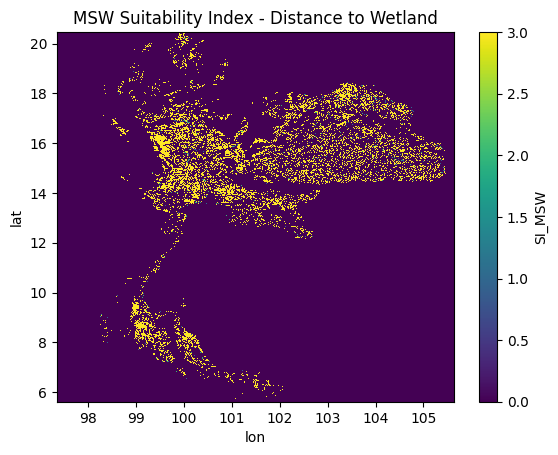

In [7]:
xr_si = xr.open_dataset("Output//xr_SI_Distancetowetland.nc")
xr_si['SI_MSW'].plot()
plt.title('MSW Suitability Index - Distance to Wetland')
plt.show()